In [7]:
import joblib
from pathlib import Path
from typing import Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# [BARU] Menambahkan confusion_matrix ke dalam daftar import
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, GroupKFold, learning_curve, ShuffleSplit

# =====================================================================
# CONFIGURASI DIREKTORI, HYPERPARAMETER & TIMESTAMP
# =====================================================================
waktu_sekarang = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Timestamp eksperimen saat ini: {waktu_sekarang}")

RANDOM_STATE = 42
N_SPLITS = 5
LABEL_COL = "label"
FILENAME_COL = "filename"

# Direktori Input & Pembuatan Folder Output Otomatis
INPUT_DIR = Path("hasil_ekstraksi")

MODEL_OUT_DIR = Path("output/models")
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

GRAPH_OUT_DIR = Path("output/grafik")
GRAPH_OUT_DIR.mkdir(parents=True, exist_ok=True)

METRIC_OUT_DIR = Path("output/metrik")
METRIC_OUT_DIR.mkdir(parents=True, exist_ok=True)

NON_FEATURE_COLS = [LABEL_COL, FILENAME_COL]

# Berkas Baseline (Data Asli Murni)
BASELINE_CSV = INPUT_DIR / "fitur_train_set.csv"

# Berkas Hasil Sampling Augmentasi Obfuskasi
AUGMENTATION_FILES = [
    "fitur_train_set_obf_ASCII_Encoding.csv",
    "fitur_train_set_obf_String_Concatenation.csv",
    "fitur_train_set_obf_String_Reordering.csv",
    "fitur_train_set_obf_Token_Manipulation.csv"
]

# Konfigurasi Hyperparameter anti-overfitting
MODELS: dict[str, Any] = {
    "RandomForest": RandomForestClassifier(
        n_jobs=-1, random_state=RANDOM_STATE, n_estimators=150, max_depth=15,
        min_samples_split=5, min_samples_leaf=2
    ),
    "XGBoost": XGBClassifier(
        n_jobs=-1, random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0,
        max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8
    ),
    "LightGBM": LGBMClassifier(
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1, max_depth=7,
        num_leaves=31, learning_rate=0.05, subsample=0.8, subsample_freq=1
    ),
}

print("✅ [CELL 0] Pustaka, Direktori Output, dan Model Berhasil Dimuat.")

Timestamp eksperimen saat ini: 20260730_140533
✅ [CELL 0] Pustaka, Direktori Output, dan Model Berhasil Dimuat.


In [8]:
def _get_feature_cols(df: pd.DataFrame) -> list[str]:
    """Mengisolasi daftar kolom fitur leksikal dan struktural dari dataframe."""
    return [c for c in df.columns if c not in NON_FEATURE_COLS]

def _evaluate_metrics(y_true: pd.Series, y_pred: np.ndarray, y_proba: np.ndarray = None) -> dict[str, float]:
    """Mengkalkulasi parameter evaluasi performa model machine learning, termasuk FPR & FNR."""
    # [BARU] Logika kalkulasi FPR dan FNR
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    else:
        fpr, fnr = 0.0, 0.0
        
    metrics = {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
        "fpr"      : fpr,
        "fnr"      : fnr
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    return metrics

def _print_formatted_results(results: dict) -> None:
    """Mencetak matriks ringkasan hasil evaluasi 5-Fold Cross Validation secara rapi."""
    # [BARU] Penyesuaian lebar kolom dan header untuk FPR dan FNR
    col_w   = [14, 12, 10, 11, 8, 10, 8, 8, 9]
    headers = ["Model", "Skenario", "Accuracy", "Precision", "Recall", "F1-Score", "FPR", "FNR", "ROC-AUC"]
    sep     = "+" + "+".join("-" * (w + 2) for w in col_w) + "+"
    header_row = "| " + " | ".join(h.ljust(col_w[i]) for i, h in enumerate(headers)) + " |"

    width = sum(col_w) + len(col_w) * 3
    print("\n" + "=" * width)
    print(f"{'TABEL MATRIKS RATA-RATA EVALUASI 5-FOLD CROSS VALIDATION':^{width}}")
    print("=" * width)
    print(sep)
    print(header_row)
    print(sep)

    for model_name, scenarios in results.items():
        for sc_name, metrics in scenarios.items():
            row = "| " + " | ".join([
                model_name.ljust(col_w[0]), sc_name.ljust(col_w[1]),
                f"{metrics['accuracy']:.4f}".ljust(col_w[2]), f"{metrics['precision']:.4f}".ljust(col_w[3]),
                f"{metrics['recall']:.4f}".ljust(col_w[4]), f"{metrics['f1']:.4f}".ljust(col_w[5]),
                f"{metrics['fpr']:.4f}".ljust(col_w[6]), f"{metrics['fnr']:.4f}".ljust(col_w[7]), # Tambahan format cetak
                f"{metrics['roc_auc']:.4f}".ljust(col_w[8]),
            ]) + " |"
            print(row)
        print(sep)

def _export_metrics_to_csv(results: dict, timestamp: str) -> None:
    """Mengekspor matriks evaluasi ke file CSV dengan timestamp."""
    records = []
    for model_name, scenarios in results.items():
        for sc_name, metrics in scenarios.items():
            records.append({
                "Model": model_name,
                "Skenario": sc_name,
                "Accuracy": metrics["accuracy"],
                "Precision": metrics["precision"],
                "Recall": metrics["recall"],
                "F1-Score": metrics["f1"],
                "FPR": metrics["fpr"], 
                "FNR": metrics["fnr"], 
                "ROC-AUC": metrics["roc_auc"]
            })
    df_metrics = pd.DataFrame(records)
    out_csv = METRIC_OUT_DIR / f"metrik_kfold_{timestamp}.csv"
    df_metrics.to_csv(out_csv, index=False)
    print(f"\n✅ Hasil 5-Fold Cross Validation tersimpan secara permanen di: {out_csv}")

def _plot_learning_curve(estimator, title: str, X: pd.DataFrame, y: pd.Series, ax) -> None:
    """Mengonstruksi kurva pembelajaran model untuk menguji underfitting/overfitting."""
    holdout_split = ShuffleSplit(n_splits=1, test_size=0.176, random_state=RANDOM_STATE)
    
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=holdout_split, n_jobs=1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Skor Latih")
    ax.plot(train_sizes, val_scores_mean, 'o-', color="orange", label="Skor Validasi")
    ax.set_title(f"{title}")
    ax.set_xlabel("Jumlah Data Latih")
    ax.set_ylabel("Akurasi")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

print("✅ [CELL 1] Fungsi Pembantu dan Ekspor Metrik Berhasil Dideklarasikan.")

✅ [CELL 1] Fungsi Pembantu dan Ekspor Metrik Berhasil Dideklarasikan.



▶ MEMULAI 5-FOLD CV DENGAN GROUP-KFOLD & ABLATION STUDY
[*] Berhasil memuat data obfuskasi terpusat dari: fitur_train_set_obf.csv (1500 Baris)

[FOLD 1/5] --------------------------------------------------
     Validasi: 990 skrip (301 malicious)
     Augmentasi: 1500 → 1187 (dihapus 313 turunan validasi)

  -> BUKTI TIDAK TERJADI LEAKAGE (Validasi R4):
     Distribusi Augmentasi Aman per fold:
teknik_obfuskasi
ASCII_Encoding          297
String_Reordering       297
Token_Manipulation      297
String_Concatenation    296

[FOLD 2/5] --------------------------------------------------
     Validasi: 990 skrip (301 malicious)
     Augmentasi: 1500 → 1200 (dihapus 300 turunan validasi)

[FOLD 3/5] --------------------------------------------------
     Validasi: 991 skrip (302 malicious)
     Augmentasi: 1500 → 1220 (dihapus 280 turunan validasi)

[FOLD 4/5] --------------------------------------------------
     Validasi: 989 skrip (301 malicious)
     Augmentasi: 1500 → 1212 (dihapus 28

c:\Users\ASUS\TA\project-ta\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\ASUS\TA\project-ta\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\ASUS\TA\project-ta\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\ASUS\TA\project-ta\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confus


[FOLD 5/5] --------------------------------------------------
     Validasi: 989 skrip (301 malicious)
     Augmentasi: 1500 → 1181 (dihapus 319 turunan validasi)

 HASIL ABLATION STUDY: BUKTI KETAHANAN FITUR AST TERHADAP OBFUSKASI

>>> Model: RandomForest
Kombinasi Fitur        | F1-Score Murni  | F1-Score Obfuskasi | Penurunan (Drop)
-------------------------------------------------------------------------------
Statistik Saja         | 0.8868          | 0.9756             | --0.0887        
Leksikal Saja          | 0.9232          | 0.9913             | --0.0681        
AST Saja               | 0.9510          | 0.9973             | --0.0464        
Stat+Lex (Tanpa AST)   | 0.9499          | 0.9883             | --0.0384        
Hybrid (Semua Fitur)   | 0.9566          | 0.9977             | --0.0411        


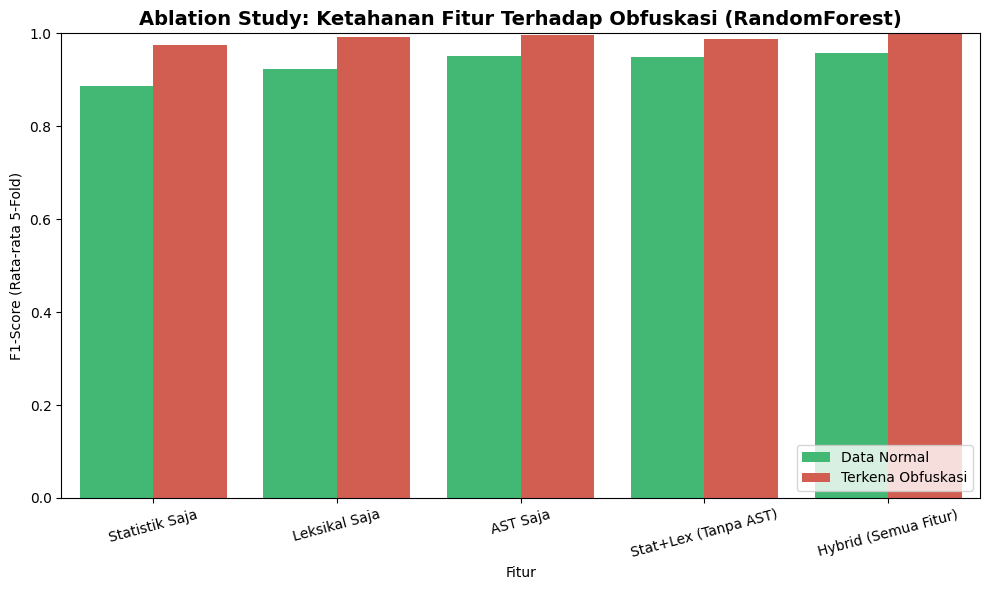


>>> Model: XGBoost
Kombinasi Fitur        | F1-Score Murni  | F1-Score Obfuskasi | Penurunan (Drop)
-------------------------------------------------------------------------------
Statistik Saja         | 0.8832          | 0.9750             | --0.0917        
Leksikal Saja          | 0.9117          | 0.9920             | --0.0802        
AST Saja               | 0.9457          | 0.9977             | --0.0520        
Stat+Lex (Tanpa AST)   | 0.9459          | 0.9880             | --0.0420        
Hybrid (Semua Fitur)   | 0.9507          | 0.9980             | --0.0473        


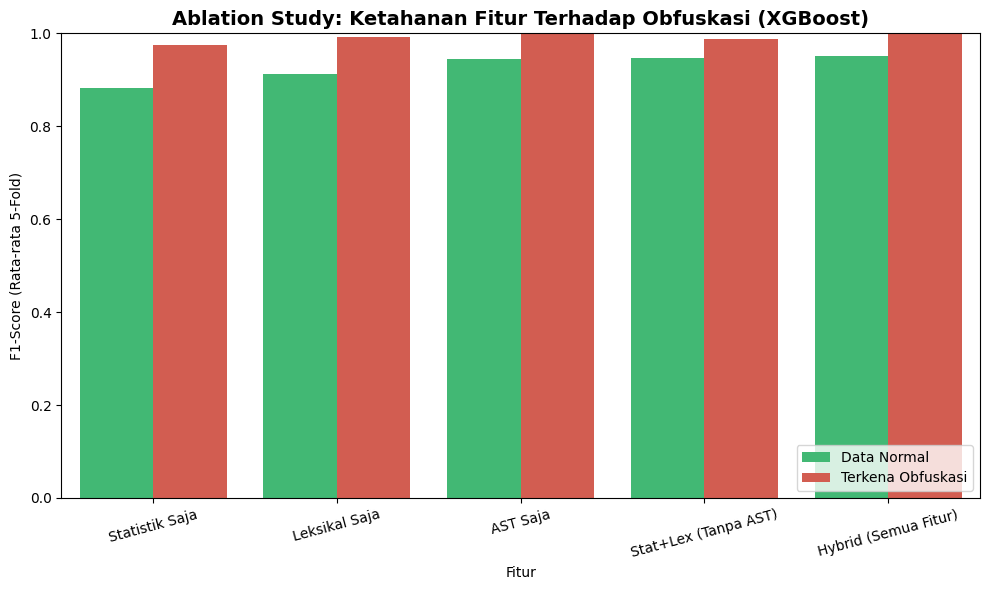


>>> Model: LightGBM
Kombinasi Fitur        | F1-Score Murni  | F1-Score Obfuskasi | Penurunan (Drop)
-------------------------------------------------------------------------------
Statistik Saja         | 0.8826          | 0.9749             | --0.0924        
Leksikal Saja          | 0.9176          | 0.9920             | --0.0744        
AST Saja               | 0.9471          | 0.9980             | --0.0509        
Stat+Lex (Tanpa AST)   | 0.9461          | 0.9883             | --0.0422        
Hybrid (Semua Fitur)   | 0.9554          | 0.9983             | --0.0429        


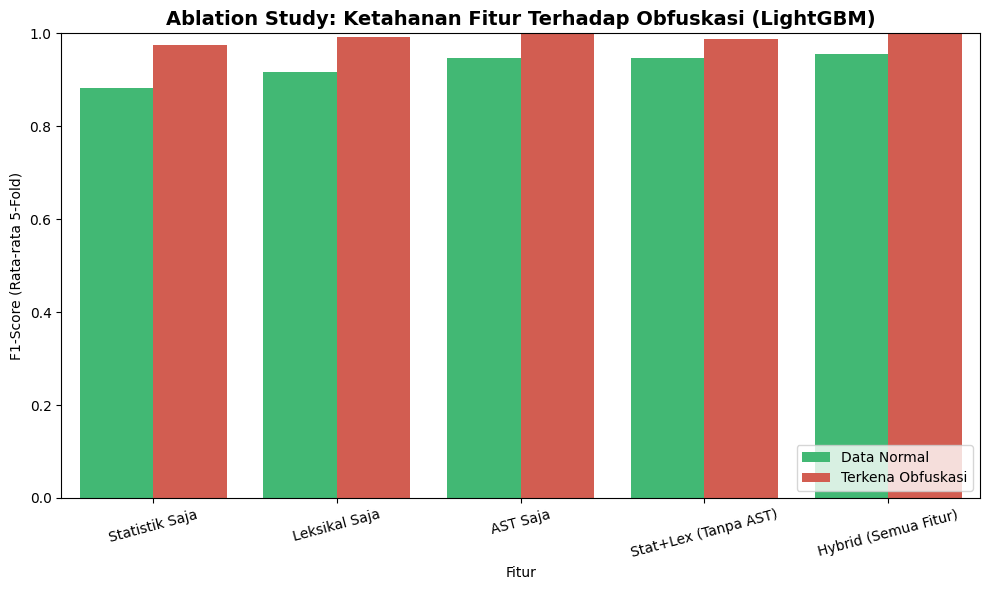


✅ Eksekusi selesai. Bukti anti-leakage tercetak dan grafik Ablation Study siap disalin ke laporan revisi.


In [9]:
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# CELL 2: ABLATION STUDY & ANTI-LEAKAGE 5-FOLD CV ENGINE (MENJAWAB R4 & R7)
# =====================================================================
print(f"\n{'='*80}")
print("▶ MEMULAI 5-FOLD CV DENGAN GROUP-KFOLD & ABLATION STUDY")
print(f"{'='*80}")

# 1. Load Data Murni (Baseline)
# PAstikan BASELINE_CSV sudah terdefinisi di Cell 0
df_murni = pd.read_csv(BASELINE_CSV)

# 2. Load Data Obfuskasi Sesuai Instruksi R4 FIX
# Kita muat HANYA dari file obfuskasi 1.500 sampel yang Anda siapkan:
OBFUSCATION_CSV = INPUT_DIR / "fitur_train_set_obf.csv"

if OBFUSCATION_CSV.exists():
    df_obf_full = pd.read_csv(OBFUSCATION_CSV)
    print(f"[*] Berhasil memuat data obfuskasi terpusat dari: {OBFUSCATION_CSV.name} ({len(df_obf_full)} Baris)")
else:
    raise FileNotFoundError(f"[!] Gagal menemukan data obfuskasi: {OBFUSCATION_CSV}")


# 3. Definisi Kelompok Fitur (Ablation Groups)
all_features = _get_feature_cols(df_murni)
feat_ast = [c for c in all_features if c.endswith('Ast')]
feat_lex = [c for c in all_features if c.startswith('tok_')]
feat_stat = [c for c in all_features if c not in feat_ast and c not in feat_lex]

ablation_groups = {
    "Statistik Saja": feat_stat,
    "Leksikal Saja": feat_lex,
    "AST Saja": feat_ast,
    "Stat+Lex (Tanpa AST)": feat_stat + feat_lex,
    "Hybrid (Semua Fitur)": all_features
}

# Inisialisasi StratifiedGroupKFold untuk Mencegah Leakage Obfuskasi (R4)
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Matriks penyimpanan hasil Ablation
ablation_results = {model: {group: {"Murni": [], "Obfuskasi": []} for group in ablation_groups} for model in MODELS}

# Memisahkan fold berdasarkan source_script_id (menggunakan kolom filename)
for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(df_murni, df_murni[LABEL_COL], groups=df_murni[FILENAME_COL]), start=1):
    print(f"\n[FOLD {fold_idx}/{N_SPLITS}] " + "-"*50)
    
    # Ekstraksi Murni
    df_fold_train = df_murni.iloc[train_idx].copy()
    df_fold_val_murni = df_murni.iloc[val_idx].copy()
    
    # ---------------------------------------------------------
    # PEMBENTUKAN AUGMENTASI DINAMIS & ANTI-LEAKAGE (R4)
    # ---------------------------------------------------------
    train_filenames = set(df_fold_train[FILENAME_COL])
    val_filenames = set(df_fold_val_murni[FILENAME_COL])
    
    # KUNCI LEAKAGE: Hapus data obfuskasi yang source-nya ada di set validasi
    df_obf_train_safe = df_obf_full[~df_obf_full[FILENAME_COL].isin(val_filenames)].copy()
    
    n_aug_sebelum = len(df_obf_full)
    n_aug_sesudah = len(df_obf_train_safe)
    n_dihapus = n_aug_sebelum - n_aug_sesudah

    # Gabungkan Data Latih (Murni + Augmentasi Aman)
    df_fold_train_aug = pd.concat([df_fold_train, df_obf_train_safe]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    
    # Set Validasi Obfuskasi (Untuk menguji ketahanan pada Ablation Study R7)
    df_fold_val_obf = df_obf_full[df_obf_full[FILENAME_COL].isin(val_filenames)].copy()
    
    val_mal_filenames = set(df_fold_val_murni[df_fold_val_murni[LABEL_COL] == 1][FILENAME_COL])
    
    print(f"     Validasi: {len(df_fold_val_murni)} skrip ({len(val_mal_filenames)} malicious)")
    print(f"     Augmentasi: {n_aug_sebelum} → {n_aug_sesudah} (dihapus {n_dihapus} turunan validasi)")
    
    if fold_idx == 1:
        print("\n  -> BUKTI TIDAK TERJADI LEAKAGE (Validasi R4):")
        print(f"     Distribusi Augmentasi Aman per fold:\n{df_obf_train_safe['teknik_obfuskasi'].value_counts().to_string()}")
    
    # ---------------------------------------------------------
    # EKSEKUSI ABLATION STUDY (R7)
    # ---------------------------------------------------------
    for model_name, model_template in MODELS.items():
        for group_name, features in ablation_groups.items():
            
            # Filter fitur berdasarkan grup ablation
            X_train = df_fold_train_aug[features]
            y_train = df_fold_train_aug[LABEL_COL]
            
            X_val_murni = df_fold_val_murni[features]
            y_val_murni = df_fold_val_murni[LABEL_COL]
            
            X_val_obf = df_fold_val_obf[features]
            y_val_obf = df_fold_val_obf[LABEL_COL]
            
            # Latih Model
            model = model_template.__class__(**model_template.get_params())
            model.fit(X_train, y_train)
            
            # Evaluasi pada data murni vs data obfuskasi (Ketahanan)
            # Pastikan fungsi _evaluate_metrics mereturn dictionary, kita panggil 'f1'
            f1_murni = _evaluate_metrics(y_val_murni, model.predict(X_val_murni))['f1']
            f1_obf = _evaluate_metrics(y_val_obf, model.predict(X_val_obf))['f1']
            
            ablation_results[model_name][group_name]["Murni"].append(f1_murni)
            ablation_results[model_name][group_name]["Obfuskasi"].append(f1_obf)

# =====================================================================
# VISUALISASI BUKTI ABLATION STUDY (R7)
# =====================================================================
print(f"\n{'='*80}")
print(" HASIL ABLATION STUDY: BUKTI KETAHANAN FITUR AST TERHADAP OBFUSKASI")
print(f"{'='*80}")

for model_name in MODELS:
    print(f"\n>>> Model: {model_name}")
    print(f"{'Kombinasi Fitur':<22} | {'F1-Score Murni':<15} | {'F1-Score Obfuskasi':<18} | {'Penurunan (Drop)':<15}")
    print("-" * 79)
    
    plot_data = []
    for group_name in ablation_groups:
        avg_murni = np.mean(ablation_results[model_name][group_name]["Murni"])
        avg_obf = np.mean(ablation_results[model_name][group_name]["Obfuskasi"])
        drop = avg_murni - avg_obf
        
        plot_data.append({"Fitur": group_name, "Data": "Data Normal", "F1-Score": avg_murni})
        plot_data.append({"Fitur": group_name, "Data": "Terkena Obfuskasi", "F1-Score": avg_obf})
        
        print(f"{group_name:<22} | {avg_murni:<15.4f} | {avg_obf:<18.4f} | -{drop:<15.4f}")
        
    # Generate Grafik untuk Laporan Sidang
    df_plot = pd.DataFrame(plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot, x="Fitur", y="F1-Score", hue="Data", palette=["#2ecc71", "#e74c3c"])
    
    plt.title(f"Ablation Study: Ketahanan Fitur Terhadap Obfuskasi ({model_name})", fontsize=14, fontweight='bold')
    plt.ylabel("F1-Score (Rata-rata 5-Fold)")
    plt.ylim(0.0, 1.0) # Menggunakan rentang penuh 0-1 agar drop terlihat drastis jika ada
    plt.xticks(rotation=15)
    plt.legend(loc='lower right')
    plt.tight_layout()
    
    file_grafik = GRAPH_OUT_DIR / f"ablation_study_{model_name}_{waktu_sekarang}.png"
    plt.savefig(file_grafik, dpi=300)
    plt.show()
    
print("\n✅ Eksekusi selesai. Bukti anti-leakage tercetak dan grafik Ablation Study siap disalin ke laporan revisi.")

▶ MULAI EKSEKUSI PIPELINE MODELING: 2026-07-30 14:06:04
[*] Memuat matriks fitur latih murni (Baseline)...
[*] Melakukan parsing komparatif 4 file teknik obfuskasi hasil sampling...
    - Terbaca sukses: fitur_train_set_obf_ASCII_Encoding.csv (375 Sampel)
    - Terbaca sukses: fitur_train_set_obf_String_Concatenation.csv (375 Sampel)
    - Terbaca sukses: fitur_train_set_obf_String_Reordering.csv (375 Sampel)
    - Terbaca sukses: fitur_train_set_obf_Token_Manipulation.csv (375 Sampel)

📊 Kesiapan Postur Dataset Latih:
   -> Volume Data Latih Baseline murni : 4,949 Baris
   -> Volume Data Augmentasi Sintetis   : 5,400 Baris

[*] Menjalankan 5-Fold Cross Validation Pipeline...
    PROTEKSI LEAKAGE: augmentasi per fold difilter berdasarkan filename

  ── Fold 1/5 ────────────────────────────────────────
     Validasi: 990 skrip (301 malicious)
     Augmentasi: 5400 → 4340 (dihapus 1060 turunan validasi)
     RandomForest   F1 Base=0.9605 | F1 Aug=0.9513
     XGBoost        F1 Base=0.9525

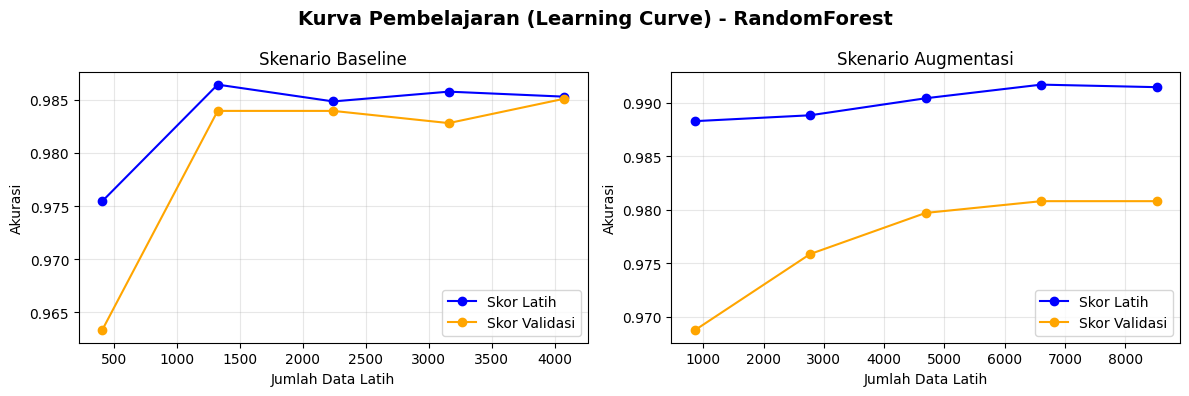

      -> Grafik Learning Curve tersimpan di: learning_curve_RandomForest_20260730_140533.png


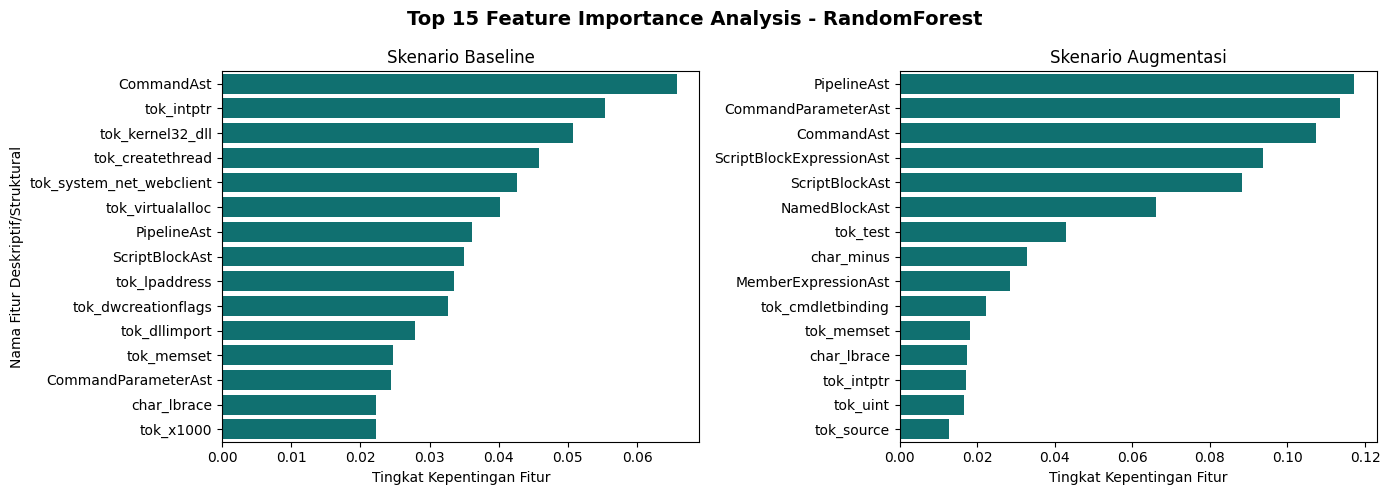

      -> Grafik Feature Importance tersimpan di: feature_importance_RandomForest_20260730_140533.png

[+] Memproses Siklus Akhir Algoritma: XGBoost...
      -> Model Baseline tersimpan di: model_XGBoost_Baseline_20260730_140533.joblib
      -> Model Augmentasi tersimpan di: model_XGBoost_Augmentasi_20260730_140533.joblib


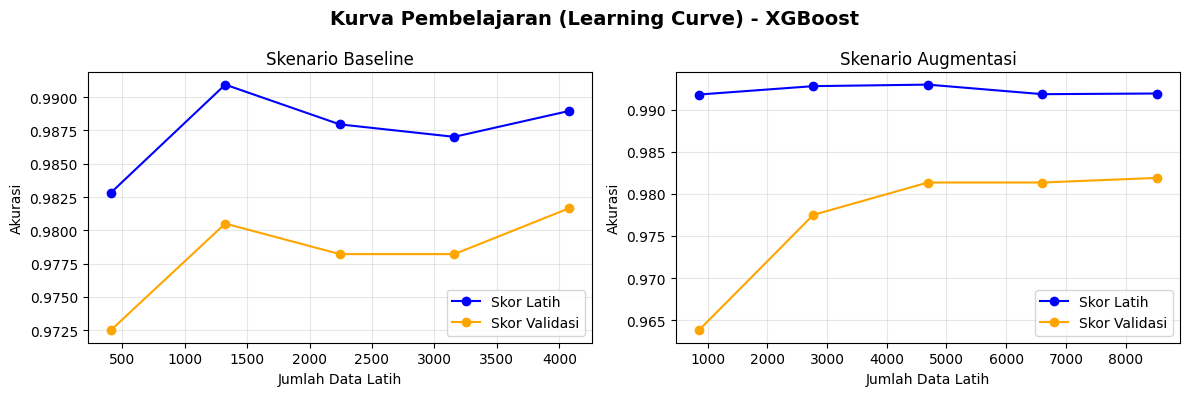

      -> Grafik Learning Curve tersimpan di: learning_curve_XGBoost_20260730_140533.png


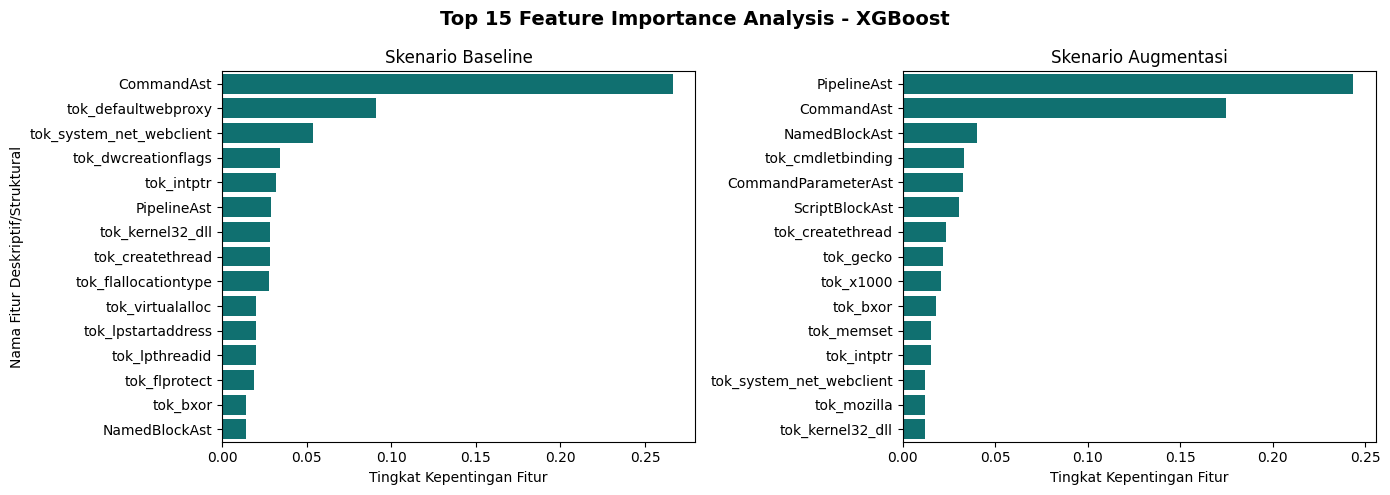

      -> Grafik Feature Importance tersimpan di: feature_importance_XGBoost_20260730_140533.png

[+] Memproses Siklus Akhir Algoritma: LightGBM...
      -> Model Baseline tersimpan di: model_LightGBM_Baseline_20260730_140533.joblib
      -> Model Augmentasi tersimpan di: model_LightGBM_Augmentasi_20260730_140533.joblib


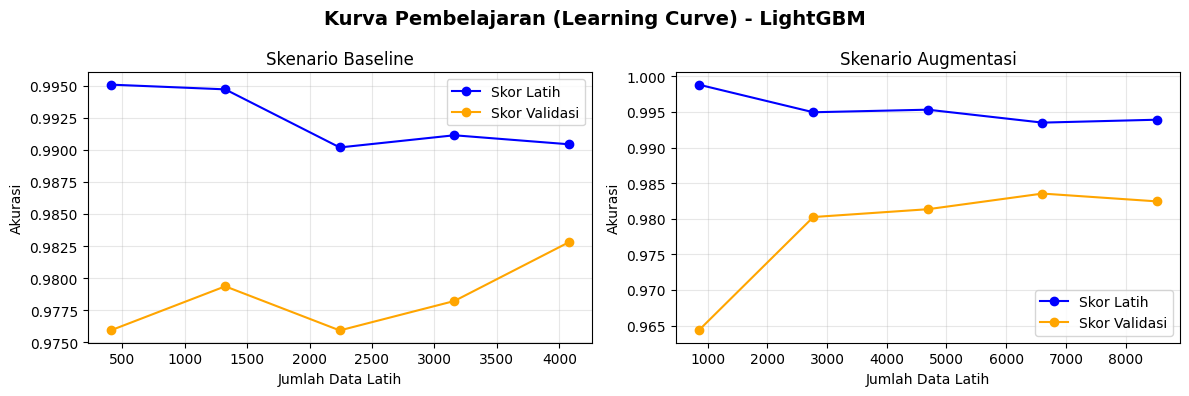

      -> Grafik Learning Curve tersimpan di: learning_curve_LightGBM_20260730_140533.png


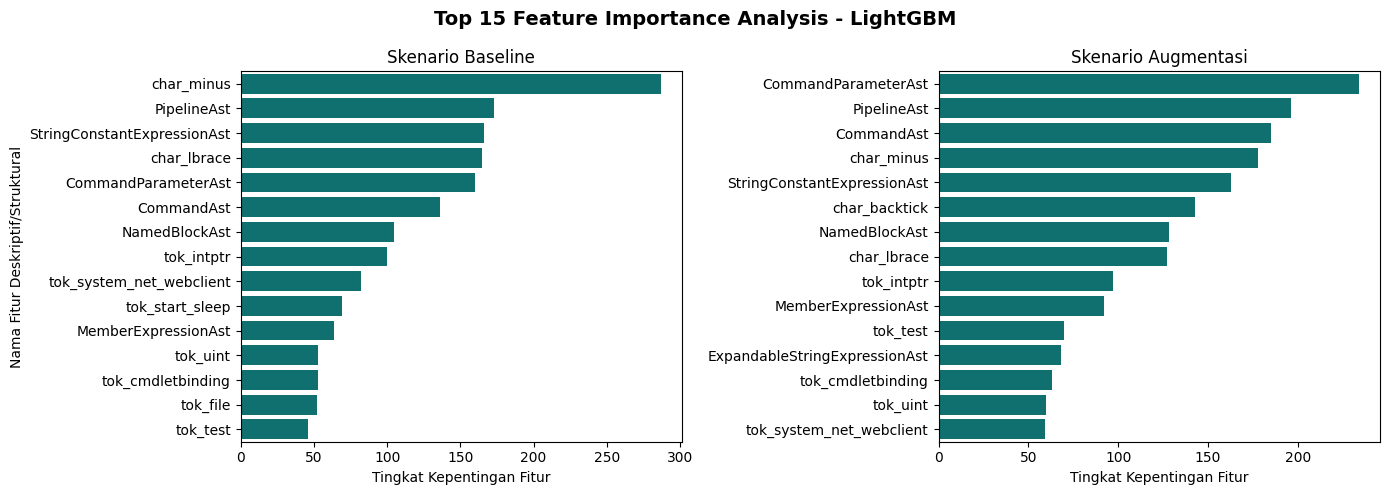

      -> Grafik Feature Importance tersimpan di: feature_importance_LightGBM_20260730_140533.png
⏹ EKSEKUSI MODELING SELESAI. Total Waktu: 0.59 Menit.


In [10]:
import time
from datetime import datetime

# =====================================================================
# EKSEKUSI PIPA UTAMA (MAIN RUN) DENGAN PENGUKUR WAKTU
# =====================================================================
print("="*80)
print(f"▶ MULAI EKSEKUSI PIPELINE MODELING: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
waktu_mulai_modeling = time.time()

if not BASELINE_CSV.exists():
    print(f"❌ [ERROR] Berkas induk murni tidak ditemukan di: {BASELINE_CSV}")
else:
    print("[*] Memuat matriks fitur latih murni (Baseline)...")
    df_train_base = pd.read_csv(BASELINE_CSV).fillna(0)

    print("[*] Melakukan parsing komparatif 4 file teknik obfuskasi hasil sampling...")
    list_df_aug = []
    for file_name in AUGMENTATION_FILES:
        # Membaca data dari INPUT_DIR
        file_path = INPUT_DIR / file_name
        if file_path.exists():
            list_df_aug.append(pd.read_csv(file_path).fillna(0))
            print(f"    - Terbaca sukses: {file_name} (375 Sampel)")
        else:
            print(f"    [!] Peringatan: Berkas berkode {file_name} tidak ditemukan di direktori!")

    if not list_df_aug:
        print("❌ [ERROR] Pipeline dibatalkan. Berkas data augmentasi tersegregasi kosong!")
    else:
        # Penyatuan terstruktur seluruh matriks augmentasi (4 * 375 = 1.500 baris)
        df_aug_1500 = pd.concat(list_df_aug, ignore_index=True)
        
        print(f"\n📊 Kesiapan Postur Dataset Latih:")
        print(f"   -> Volume Data Latih Baseline murni : {len(df_train_base):,} Baris")
        print(f"   -> Volume Data Augmentasi Sintetis   : {len(df_aug_1500):,} Baris\n")

        # Eksekusi Tahap 1: Evaluasi Silang K-Fold Kontrol
        summary_results = run_kfold_cross_validation(df_train_base, df_aug_1500)
        _print_formatted_results(summary_results)
        
        # Simpan CSV metrik hasil K-Fold secara permanen
        _export_metrics_to_csv(summary_results, waktu_sekarang)
        
        # Eksekusi Tahap 2: Retrain Massal, Ekspor Serializer, dan Pembuatan Diagram
        fit_and_export_final_models(df_train_base, df_aug_1500)

# Kalkulasi durasi akhir
durasi_modeling = (time.time() - waktu_mulai_modeling) / 60
print("="*80)
print(f"⏹ EKSEKUSI MODELING SELESAI. Total Waktu: {durasi_modeling:.2f} Menit.")
print("="*80)

ABLATION STUDY — KONTRIBUSI PER KELOMPOK FITUR

Kolom fitur per kelompok:
  Statistik   : 4 fitur
  Leksikal    : 111 fitur
  AST         : 12 fitur
  Total       : 127 fitur

Konfigurasi ablation: 7
  Statistik                : 4 fitur
  Leksikal                 : 111 fitur
  AST                      : 12 fitur
  Statistik+Leksikal       : 115 fitur
  Statistik+AST            : 16 fitur
  Leksikal+AST             : 123 fitur
  Semua (S+L+A)            : 127 fitur

[*] Ablation: Statistik (4 fitur)...
    F1=0.8585 | Acc=0.9077 | Recall=0.9197 | AUC=0.9584

[*] Ablation: Leksikal (111 fitur)...
    F1=0.9048 | Acc=0.9392 | Recall=0.9495 | AUC=0.9895

[*] Ablation: AST (12 fitur)...
    F1=0.9473 | Acc=0.9687 | Recall=0.9256 | AUC=0.9867

[*] Ablation: Statistik+Leksikal (115 fitur)...
    F1=0.9269 | Acc=0.9543 | Recall=0.9509 | AUC=0.9921

[*] Ablation: Statistik+AST (16 fitur)...
    F1=0.9494 | Acc=0.9699 | Recall=0.9296 | AUC=0.9875

[*] Ablation: Leksikal+AST (123 fitur)...
    F1

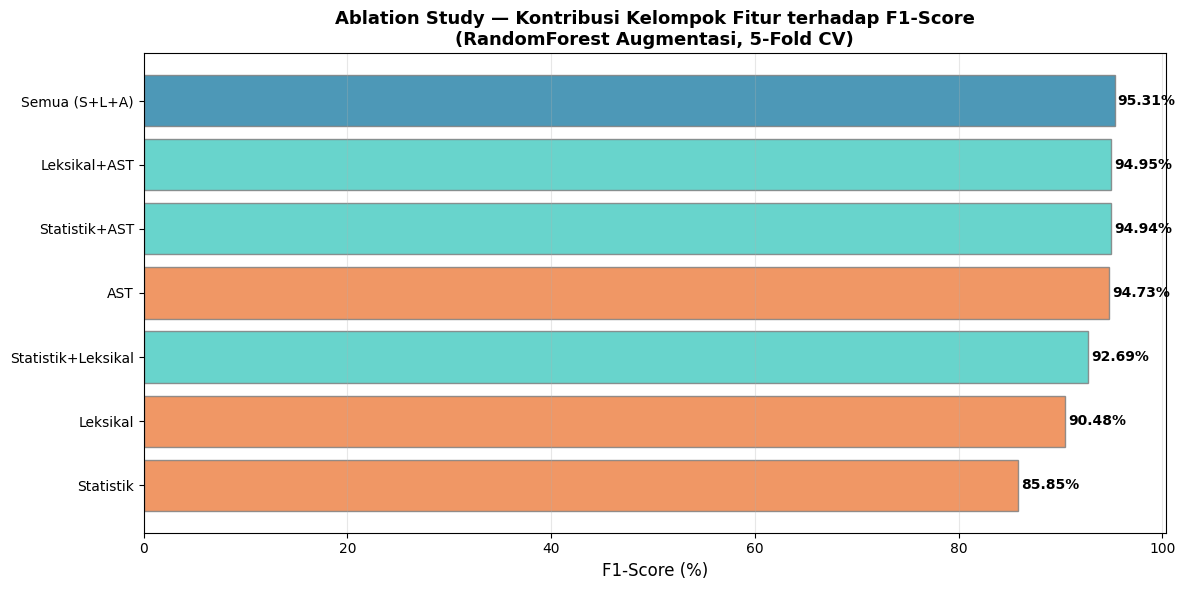

Grafik ablation F1 tersimpan: ablation_f1_20260730_140533.png


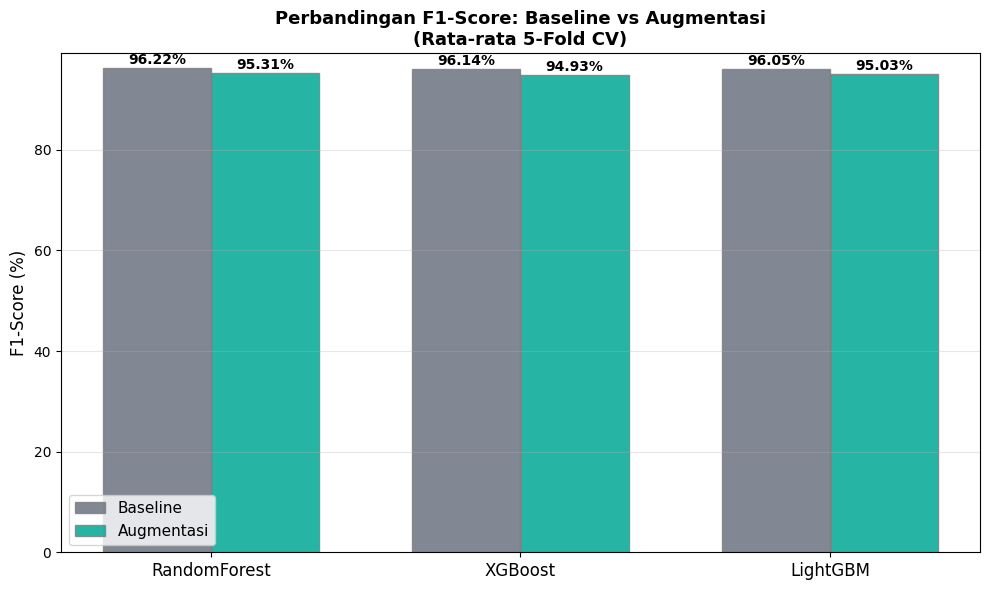

Grafik perbandingan F1 tersimpan: f1_baseline_vs_augmentasi_20260730_140533.png


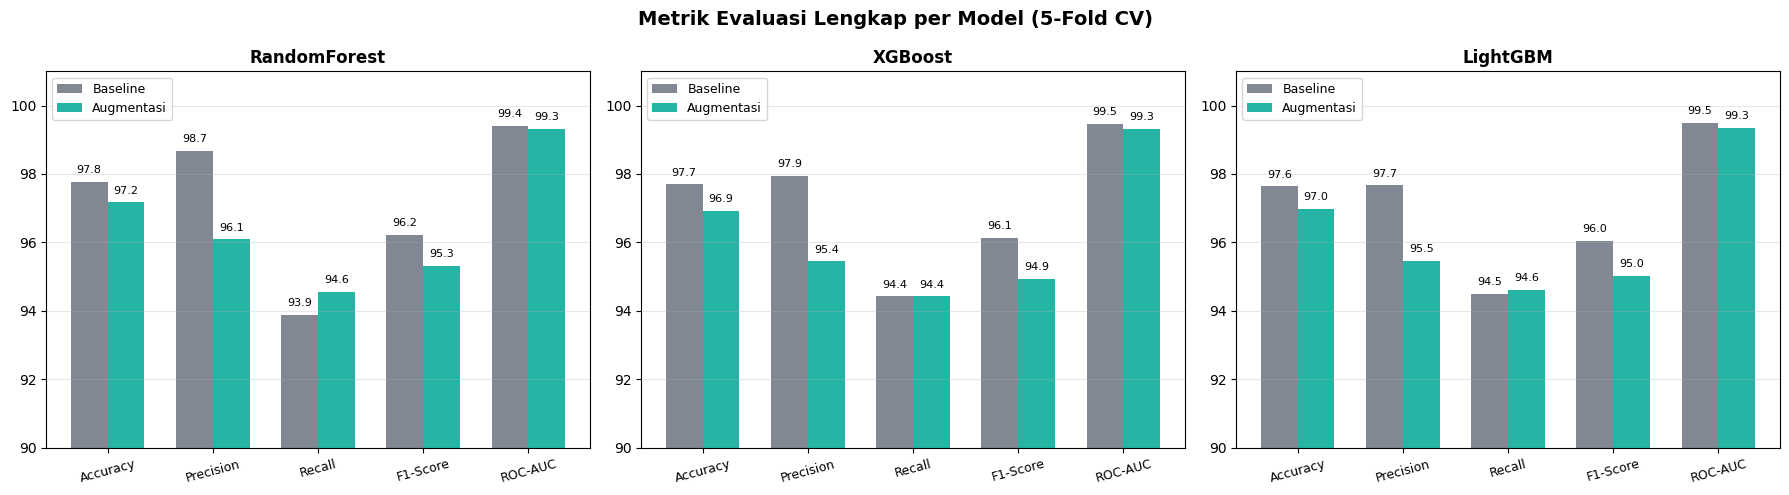

Grafik metrik lengkap tersimpan: metrik_lengkap_per_model_20260730_140533.png

✅ Ablation study + visualisasi selesai. Waktu: 0.44 menit.


In [11]:
# =====================================================================
# CELL 5 — R7: ABLATION STUDY + VISUALISASI DIAGRAM BATANG
#
# Membuktikan kontribusi setiap kelompok fitur (Statistik, Leksikal, AST)
# terhadap performa model, baik secara individual maupun kombinasi.
# Feature importance tidak cukup — ablation study menunjukkan dampak
# kausal penghapusan fitur terhadap metrik evaluasi.
# =====================================================================
import time
from itertools import combinations

print("=" * 80)
print("ABLATION STUDY — KONTRIBUSI PER KELOMPOK FITUR")
print("=" * 80)
t_start = time.time()

# ── Identifikasi kelompok fitur dari kolom CSV ────────────────────────
feature_cols_all = _get_feature_cols(df_train_base)

KELOMPOK = {
    "Statistik": [c for c in feature_cols_all
                  if not c.startswith("tok_") and not c.endswith("Ast")],
    "Leksikal":  [c for c in feature_cols_all if c.startswith("tok_")],
    "AST":       [c for c in feature_cols_all if c.endswith("Ast")],
}

print(f"\nKolom fitur per kelompok:")
for k, cols in KELOMPOK.items():
    print(f"  {k:<12}: {len(cols)} fitur")
print(f"  {'Total':<12}: {sum(len(v) for v in KELOMPOK.values())} fitur")

# ── Definisi konfigurasi ablation ─────────────────────────────────────
# 7 konfigurasi: 3 individual + 3 pasangan + 1 lengkap
ablation_configs = {}

# Individual
for nama, cols in KELOMPOK.items():
    ablation_configs[nama] = cols

# Pasangan
for (n1, c1), (n2, c2) in combinations(KELOMPOK.items(), 2):
    nama = f"{n1}+{n2}"
    ablation_configs[nama] = c1 + c2

# Lengkap (referensi)
ablation_configs["Semua (S+L+A)"] = feature_cols_all

print(f"\nKonfigurasi ablation: {len(ablation_configs)}")
for nama, cols in ablation_configs.items():
    print(f"  {nama:<25}: {len(cols)} fitur")

# ── Jalankan CV per konfigurasi ───────────────────────────────────────
skf_abl = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Gunakan model terbaik: RandomForest Augmentasi
MODEL_ABL = MODELS["RandomForest"]

ablation_results = {}

for config_name, config_cols in ablation_configs.items():
    print(f"\n[*] Ablation: {config_name} ({len(config_cols)} fitur)...")
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(
        skf_abl.split(df_train_base, df_train_base[LABEL_COL]), start=1
    ):
        df_fold_train = df_train_base.iloc[train_idx]
        df_fold_val   = df_train_base.iloc[val_idx]

        # Proteksi leakage augmentasi (R4)
        val_mal_fnames = set(
            df_fold_val[df_fold_val[LABEL_COL] == 1][FILENAME_COL].tolist()
        )
        df_aug_safe = df_aug_1500[~df_aug_1500[FILENAME_COL].isin(val_mal_fnames)]

        # Gabung training + augmentasi aman
        df_combined = pd.concat([df_fold_train, df_aug_safe]).sample(
            frac=1, random_state=RANDOM_STATE
        ).reset_index(drop=True)

        # Pastikan semua kolom config ada
        cols_ada = [c for c in config_cols if c in df_combined.columns]

        X_train = df_combined[cols_ada]
        y_train = df_combined[LABEL_COL]
        X_val   = df_fold_val[cols_ada]
        y_val   = df_fold_val[LABEL_COL]

        model = MODEL_ABL.__class__(**MODEL_ABL.get_params())
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
        fold_scores.append(_evaluate_metrics(y_val, y_pred, y_proba))

    # Rata-rata fold
    avg = {
        metric: float(np.mean([fs[metric] for fs in fold_scores]))
        for metric in ("accuracy", "precision", "recall", "f1", "fpr", "fnr", "roc_auc")
    }
    ablation_results[config_name] = avg
    print(f"    F1={avg['f1']:.4f} | Acc={avg['accuracy']:.4f} | Recall={avg['recall']:.4f} | AUC={avg['roc_auc']:.4f}")

# ── Tabel Ringkasan Ablation ─────────────────────────────────────────
print(f"\n{'='*90}")
print(f"{'TABEL ABLATION STUDY — RandomForest Augmentasi':^90}")
print(f"{'='*90}")
print(f"{'Konfigurasi':<25} {'Fitur':>6} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 90)
for name, m in sorted(ablation_results.items(), key=lambda x: -x[1]['f1']):
    n_feat = len(ablation_configs[name])
    print(f"{name:<25} {n_feat:>6} {m['accuracy']:>10.4f} {m['precision']:>11.4f} {m['recall']:>8.4f} {m['f1']:>8.4f} {m['roc_auc']:>8.4f}")
print("=" * 90)

# ── Simpan CSV ablation ──────────────────────────────────────────────
abl_records = []
for name, m in ablation_results.items():
    abl_records.append({
        "Konfigurasi": name, "Jumlah_Fitur": len(ablation_configs[name]),
        **{k.upper(): round(v, 4) for k, v in m.items()}
    })
df_abl = pd.DataFrame(abl_records).sort_values("F1", ascending=False)
abl_csv = METRIC_OUT_DIR / f"ablation_study_{waktu_sekarang}.csv"
df_abl.to_csv(abl_csv, index=False)
print(f"\n✅ Ablation CSV tersimpan: {abl_csv}")

# ═════════════════════════════════════════════════════════════════════
# VISUALISASI DIAGRAM BATANG
# ═════════════════════════════════════════════════════════════════════

# ── Grafik 1: Ablation Study F1-Score ─────────────────────────────────
sorted_configs = sorted(ablation_results.items(), key=lambda x: x[1]['f1'])
names_abl  = [c[0] for c in sorted_configs]
f1_abl     = [c[1]['f1'] * 100 for c in sorted_configs]
recall_abl = [c[1]['recall'] * 100 for c in sorted_configs]

WARNA_ABL = []
for n in names_abl:
    if n == "Semua (S+L+A)":   WARNA_ABL.append("#2E86AB")
    elif "+" in n:              WARNA_ABL.append("#4ECDC4")
    else:                       WARNA_ABL.append("#EE854A")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(names_abl, f1_abl, color=WARNA_ABL, alpha=0.85, edgecolor="gray")
for bar, val in zip(bars, f1_abl):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("F1-Score (%)", fontsize=12)
ax.set_title("Ablation Study — Kontribusi Kelompok Fitur terhadap F1-Score\n(RandomForest Augmentasi, 5-Fold CV)",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, max(f1_abl) + 5)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
file_abl1 = GRAPH_OUT_DIR / f"ablation_f1_{waktu_sekarang}.png"
plt.savefig(file_abl1, dpi=300, bbox_inches="tight")
plt.show()
print(f"Grafik ablation F1 tersimpan: {file_abl1.name}")

# ── Grafik 2: Perbandingan F1 Baseline vs Augmentasi per Model ───────
if 'summary_results' in dir() or 'summary_results' in globals():
    models_list = list(summary_results.keys())
    f1_base = [summary_results[m]["Baseline"]["f1"] * 100 for m in models_list]
    f1_aug  = [summary_results[m]["Augmentasi"]["f1"] * 100 for m in models_list]

    x = np.arange(len(models_list))
    w = 0.35

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    bars_b = ax2.bar(x - w/2, f1_base, w, label="Baseline", color="#6B7280", alpha=0.85, edgecolor="gray")
    bars_a = ax2.bar(x + w/2, f1_aug,  w, label="Augmentasi", color="#00A896", alpha=0.85, edgecolor="gray")

    for bar in list(bars_b) + list(bars_a):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax2.set_xticks(x)
    ax2.set_xticklabels(models_list, fontsize=12)
    ax2.set_ylabel("F1-Score (%)", fontsize=12)
    ax2.set_title("Perbandingan F1-Score: Baseline vs Augmentasi\n(Rata-rata 5-Fold CV)", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=11)
    ax2.grid(axis="y", alpha=0.3)
    ax2.set_ylim(0, max(max(f1_base), max(f1_aug)) + 3)
    plt.tight_layout()

    file_cmp = GRAPH_OUT_DIR / f"f1_baseline_vs_augmentasi_{waktu_sekarang}.png"
    plt.savefig(file_cmp, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Grafik perbandingan F1 tersimpan: {file_cmp.name}")

# ── Grafik 3: Metrik lengkap per model (grouped bar) ─────────────────
if 'summary_results' in dir() or 'summary_results' in globals():
    metrik_list = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    metrik_label = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

    fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
    for idx, model_name in enumerate(models_list):
        ax = axes3[idx]
        base_vals = [summary_results[model_name]["Baseline"][m] * 100 for m in metrik_list]
        aug_vals  = [summary_results[model_name]["Augmentasi"][m] * 100 for m in metrik_list]

        x = np.arange(len(metrik_list))
        bars_b = ax.bar(x - w/2, base_vals, w, label="Baseline", color="#6B7280", alpha=0.85)
        bars_a = ax.bar(x + w/2, aug_vals,  w, label="Augmentasi", color="#00A896", alpha=0.85)

        for bar in list(bars_b) + list(bars_a):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(metrik_label, fontsize=9, rotation=15)
        ax.set_title(model_name, fontsize=12, fontweight="bold")
        ax.set_ylim(90, 101)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)

    fig3.suptitle("Metrik Evaluasi Lengkap per Model (5-Fold CV)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    file_m3 = GRAPH_OUT_DIR / f"metrik_lengkap_per_model_{waktu_sekarang}.png"
    plt.savefig(file_m3, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Grafik metrik lengkap tersimpan: {file_m3.name}")

durasi_abl = (time.time() - t_start) / 60
print(f"\n✅ Ablation study + visualisasi selesai. Waktu: {durasi_abl:.2f} menit.")
